refer `D03`,`D06`

In [1]:
import crypy as cp
import numpy as np
from matplotlib import pyplot as plt
from crypy_examples.atom_network import (
    draw_atom, 
    draw_bond,
    color_bond,
    color_Se,
    color_Ta,
    r_Se,
    r_Ta,
    r_bond,
    a1,a2,
    p1,p2,p3,p4        
)
from crypy_examples.chiral_interlock import lattice_points_in_hex
from matplotlib.colors import to_rgb

# region Fundamental Parameters
xylim = ((-10,10),(-10,10))

In [2]:
color_Se_HA = [254,164,0]
color_Ta_HA = [0, 176, 240]
color_hollow = [255, 0, 150]
color_Se_vesta = [202,137,33]
color_Ta_vesta = [38,115,148]
hexer =  lambda rgb: '#{:02x}{:02x}{:02x}'.format(*rgb)

In [75]:
def draw_latt():
    # region class setup for figure
    # region LEVEL 1: ATOMIC LATTICE
    pv = cp.PrimitiveVector2D(a1,a2)
    bss = cp.Basis2D(pv)
    # gen_atom_Ta = lambda x,y: draw_atom(x, y, radius=r_Ta, color_hex=color_Ta)
    gen_atom_Ta = lambda x,y: draw_atom(x, y, radius=r_Ta*.6*1.5, color_hex=hexer(color_Ta_HA))
    gen_atom_Se = lambda x,y: draw_atom(x, y, radius=r_Se*1.5, color_hex=hexer(color_Se_HA))
    gen_atom_Ta = lambda x,y: cp.Collection.Generator.gen_regular_polygon(
        3,x=x,y=y,r=.2,c=hexer(color_Ta_HA),phi=np.pi/2)
    gen_atom_Se = lambda x,y: cp.Collection.Generator.gen_regular_polygon(
        3,x=x,y=y,r=.2,c=hexer(color_Se_HA),phi=-np.pi/2)
    bss.add_artist(gen_atom_Ta,(p1),label='Ta')
    bss.add_artist(gen_atom_Se,(p2),label='Se')



    lp = cp.LatticePoints2D(pv) 
    lp.generate_points_by_xylim(*xylim)
    cry = cp.Crystal2D(bss,lp)
    # endregion

    # region LEVEL 2: CDW 
    
    gen_domain = lambda x,y:cry_sup.plot_crystal(x,y)
    # endregion
    # endregion
    fig,ax  = cry.plot_crystal()
    # cry_sup.plot_crystal()
    ax.set_xlim(-4,4)

    ax.set_ylim(-4,4)
    ax.set_xticks([])
    ax.set_yticks([])

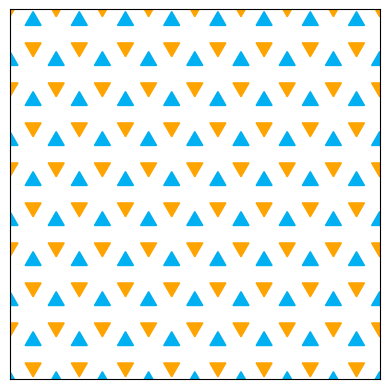

In [76]:
draw_latt()

In [80]:
def draw_center(pos_CDW,clr_CDW=color_hollow):
    # region class setup for figure
    # region LEVEL 1: ATOMIC LATTICE
    pv = cp.PrimitiveVector2D(a1,a2)
    bss = cp.Basis2D(pv)
    # gen_atom_Ta = lambda x,y: draw_atom(x, y, radius=r_Ta, color_hex=color_Ta)
    gen_atom_Ta = lambda x,y: draw_atom(x, y, radius=r_Ta*.6*1.5, color_hex=hexer(color_Ta_HA))
    gen_atom_Se = lambda x,y: draw_atom(x, y, radius=r_Se*1.5, color_hex=hexer(color_Se_HA))
    gen_atom_Ta = lambda x,y: cp.Collection.Generator.gen_regular_polygon(
        3,x=x,y=y,r=.2,c=hexer(color_Ta_HA),phi=np.pi/2)
    gen_atom_Se = lambda x,y: cp.Collection.Generator.gen_regular_polygon(
        3,x=x,y=y,r=.2,c=hexer(color_Se_HA),phi=-np.pi/2)
    bss.add_artist(gen_atom_Ta,(p1),label='Ta')
    bss.add_artist(gen_atom_Se,(p2),label='Se')



    lp = cp.LatticePoints2D(pv) 
    lp.generate_points_by_xylim(*xylim)
    cry = cp.Crystal2D(bss,lp)
    # endregion

    # region LEVEL 2: CDW 
    pv_sup = pv.get_super_structure(3,3)
    bss_sup = cp.Basis2D(pv_sup)
    def gen_CDW(x,y):    
        ec = np.array(clr_CDW)/255
        ec = np.append(ec,0.6)
        cp.Collection.Generator.gen_regular_polygon(
        30,x=x,y=y,r=1,fc=(0,0,0,0),ec = ec)
        cp.Collection.Generator.gen_regular_polygon(
        30,x=x,y=y,r=.3,fc=(0,0,0,0),ec = ec)
    bss_sup.add_artist(gen_CDW,pos_CDW,label='CDW')
    lp_sup = cp.LatticePoints2D(pv_sup)   
    lp_sup.generate_points_by_xylim(*xylim)
    cry_sup = cp.Crystal2D(bss_sup,lp_sup)
    gen_domain = lambda x,y:cry_sup.plot_crystal(x,y)
    # endregion
    # endregion
    # fig,ax  = cry.plot_crystal()
    fig,ax = cry_sup.plot_crystal()
    ax.set_xlim(-4,4)

    ax.set_ylim(-4,4)
    ax.set_xticks([])
    ax.set_yticks([])

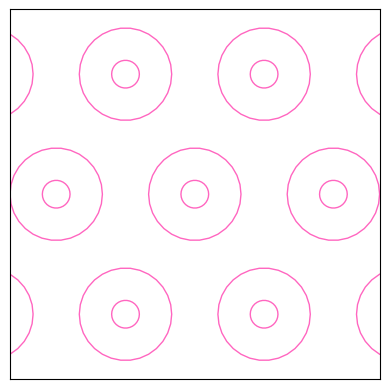

In [81]:
draw_center(np.array([0,0]))

In [3]:
def draw(pos_CDW,clr_CDW=color_hollow):
    # region class setup for figure
    # region LEVEL 1: ATOMIC LATTICE
    pv = cp.PrimitiveVector2D(a1,a2)
    bss = cp.Basis2D(pv)
    # gen_atom_Ta = lambda x,y: draw_atom(x, y, radius=r_Ta, color_hex=color_Ta)
    gen_atom_Ta = lambda x,y: draw_atom(x, y, radius=r_Ta*.6*1.5, color_hex=hexer(color_Ta_HA))
    gen_atom_Se = lambda x,y: draw_atom(x, y, radius=r_Se*1.5, color_hex=hexer(color_Se_HA))
    gen_atom_Ta = lambda x,y: cp.Collection.Generator.gen_regular_polygon(
        3,x=x,y=y,r=.2,c=hexer(color_Ta_HA),phi=np.pi/2)
    gen_atom_Se = lambda x,y: cp.Collection.Generator.gen_regular_polygon(
        3,x=x,y=y,r=.2,c=hexer(color_Se_HA),phi=-np.pi/2)
    bss.add_artist(gen_atom_Ta,(p1),label='Ta')
    bss.add_artist(gen_atom_Se,(p2),label='Se')



    lp = cp.LatticePoints2D(pv) 
    lp.generate_points_by_xylim(*xylim)
    cry = cp.Crystal2D(bss,lp)
    # endregion

    # region LEVEL 2: CDW 
    pv_sup = pv.get_super_structure(3,3)
    bss_sup = cp.Basis2D(pv_sup)
    def gen_CDW(x,y):    
        ec = np.array(clr_CDW)/255
        ec = np.append(ec,0.6)
        cp.Collection.Generator.gen_regular_polygon(
        30,x=x,y=y,r=1,fc=(0,0,0,0),ec = ec)
        cp.Collection.Generator.gen_regular_polygon(
        30,x=x,y=y,r=.3,fc=(0,0,0,0),ec = ec)
    bss_sup.add_artist(gen_CDW,pos_CDW,label='CDW')
    lp_sup = cp.LatticePoints2D(pv_sup)   
    lp_sup.generate_points_by_xylim(*xylim)
    cry_sup = cp.Crystal2D(bss_sup,lp_sup)
    gen_domain = lambda x,y:cry_sup.plot_crystal(x,y)
    # endregion
    # endregion
    fig,ax  = cry.plot_crystal()
    cry_sup.plot_crystal()
    ax.set_xlim(-4,4)

    ax.set_ylim(-4,4)
    ax.set_xticks([])
    ax.set_yticks([])



In [ ]:
# region plot
plt.figure()
fig,axs = plt.subplots(1,3,figsize=(6,2))
plt.sca(axs[0])
draw(pos_CDW=[0,0],clr_CDW=color_hollow)
plt.sca(axs[1])
draw(pos_CDW=p1/3,clr_CDW=color_hollow)    
plt.sca(axs[2])
draw(pos_CDW=p2/3,clr_CDW=color_hollow)    
plt.savefig("D03_CDW_toon2.svg", bbox_inches='tight')

<Figure size 640x480 with 0 Axes>

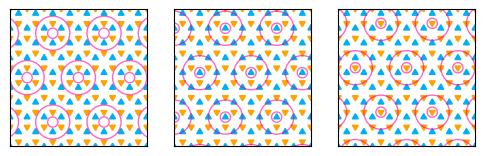

In [4]:
# region plot
plt.figure()
fig,axs = plt.subplots(1,3,figsize=(6,2))
plt.sca(axs[0])
draw(pos_CDW=[0,0],clr_CDW=color_hollow)
plt.sca(axs[1])
draw(pos_CDW=p1/3,clr_CDW=color_hollow)    
plt.sca(axs[2])
draw(pos_CDW=p2/3,clr_CDW=color_hollow)    
plt.savefig("D03_CDW_toon2.svg", bbox_inches='tight')

In [5]:
c = np.array(color_hollow)/255
c = np.append(c,0.6)
ccc =(c,c,c)

In [8]:
a = np.array([1,2,3])
b = np.array([[3],[3],[2]])
b+ a

array([[4, 5, 6],
       [4, 5, 6],
       [3, 4, 5]])

In [9]:
a.reshape((-1,1))


array([[1],
       [2],
       [3]])

In [ ]:
def from_phi123_to_n12t(phi123):
    """transformation from (phi1,phi2,phi3) to (n1,n2,t)
    Args:
        phi123: 3tuple,list,array
    Returns:
        n12t: 3 array
    Raises:
    """
    phi123 = np.array(phi123) # here phi123 should be (3,)
    phi123_ = phi123 - np.array([1,0,0])
    
    T = np.array([
    [0,-1,1],[1,0,1],[-1,1,1]
    ])
    T_inv = np.linalg.inv(T)
    n12t = T_inv@phi123_
    return n12t

In [33]:
from_phi123_to_n12t([0,0,0])

array([ 0.33333333,  0.66666667, -0.33333333])

In [72]:
color_hollow

[255, 0, 150]

In [ ]:
def draw2(phis,n1n2,ax,mod=0):
    if mod == 0:
        print("all")
    elif mod == 1:
        print("k plane")
    elif mod == 2:
        print("CDW center")
    O = np.array((0,1/(np.sqrt(3))))
    ks = np.array(((0,1),(-np.sqrt(3)/2, -1/2),(np.sqrt(3)/2, -1/2)))
    ks = ks*(2/(3*np.sqrt(3)))
    for k,ik in zip(ks[:3],range(3)):
        k_abs = np.linalg.vector_norm(k)
        d = k/(k_abs**2)
        lines = cp.Collection.plot_plane_wave_lines(
            k=k, color=ccc, ax=ax,
            origin=O+d*phis[ik]*(2/3))
    draw(pos_CDW=+np.array(n1n2)/3,clr_CDW=color_hollow)

In [87]:
def draw_k(phis,ax):
    O = np.array((0,1/(np.sqrt(3))))
    ks = np.array(((0,1),(-np.sqrt(3)/2, -1/2),(np.sqrt(3)/2, -1/2)))
    ks = ks*(2/(3*np.sqrt(3)))
    for k,ik in zip(ks[:3],range(3)):
        k_abs = np.linalg.vector_norm(k)
        d = k/(k_abs**2)
        lines = cp.Collection.plot_plane_wave_lines(
            k=k, color=ccc, ax=ax,
            origin=O+d*phis[ik]*(2/3))    

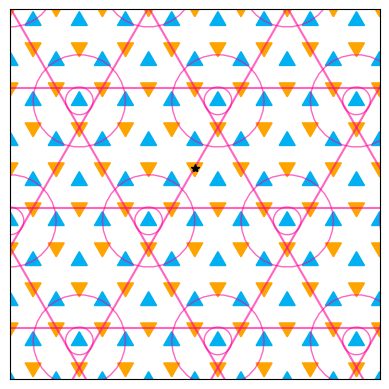

In [65]:
phis = [1,-2,0]
n1n2 = from_phi123_to_n12t(phis)
n1n2 = n1n2[:-1]

O = np.array((0,1/(np.sqrt(3))))
ks = np.array(
    ((0,1),(-np.sqrt(3)/2, -1/2),(+np.sqrt(3)/2, -1/2))
    )
ks = ks*(2/(3*np.sqrt(3)))
ax = plt.axes()
for k,ik in zip(ks[:3],range(3)):
    k_abs = np.linalg.vector_norm(k)
    d = k/(k_abs**2)
    lines = cp.Collection.plot_plane_wave_lines(
        k=k, color=ccc, ax=ax,
        origin=O+d*phis[ik]*(2/3))
draw(pos_CDW=n1n2/3,clr_CDW=color_hollow)
plt.plot(O[0],O[1],'k*')


In [25]:
phiss = [
    [0,1,-1],
    [1,0,0],
    [1,1,0],
    [0,1,0]
]
n1n2s = list(map(from_phi123_to_n12t,phiss))

In [26]:
n1n2s[0]

array([ 1.33333333,  0.66666667, -0.33333333])

In [ ]:



msb,nsb = 2,4
fig,axs = plt.subplots(msb,nsb,figsize=(8,4))
for isb in range(msb):
    for jsb in range(nsb):
        phis = phiss[jsb]
        n1n2=n1n2s[jsb
        ]
        ax = axs[isb,jsb]
        plt.sca(ax)
        plt.plot(2,3)
        # draw(pos_CDW=p2/3+np.array(n1n2),clr_CDW=color_hollow)
        draw2(phis,n1n2,ax=ax)
        plt.plot(O[0],O[1],'k*')


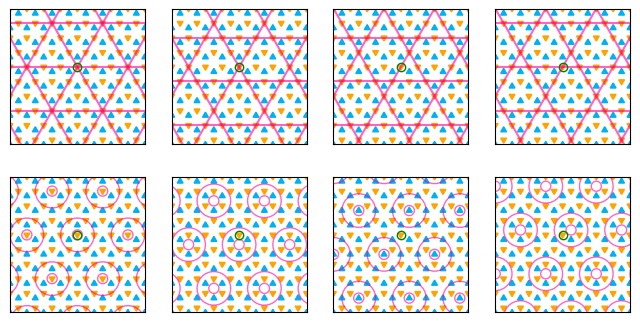

In [88]:
phiss = [
    [0,0,0],
    [1,0,0],
    [1,-2,0],
    [0,1,0]
]
n1n2s = list(map(from_phi123_to_n12t,phiss))
msb,nsb = 2,4
fig,axs = plt.subplots(msb,nsb,figsize=(8,4))
for isb in range(msb):
    for jsb in range(nsb):
        phis = phiss[jsb]
        n1n2=n1n2s[jsb
        ]
        ax = axs[isb,jsb]
        plt.sca(ax)
        # draw(pos_CDW=p2/3+np.array(n1n2),clr_CDW=color_hollow)
        # draw2(phis,n1n2[:-1],ax=ax)
        draw_latt()
        if isb == 1:
            draw_center(pos_CDW=n1n2[:-1]/3)
        elif isb == 0:
            draw_k(phis=phis,ax=ax)
        plt.plot(O[0],O[1],'go',markerfacecolor='none')
